# Examen Final — ICCD753 Recuperación de Información

## Sistema RAG sobre abstracts de arXiv

**Carolina Ayala** — EPN, Facultad de Ingeniería de Sistemas

Este notebook implementa un sistema **RAG (Retrieval-Augmented Generation)** completo que responde preguntas sobre investigación en Machine Learning / IA usando como base de conocimiento ~39k abstracts de papers de arXiv.

El pipeline es:

```
corpus arXiv → embeddings (all-mpnet-base-v2) → índice vectorial (ChromaDB, coseno)
      → retrieval denso top-20 → re-ranking cross-encoder → top-5
      → prompt con evidencias → Gemini 2.5 Flash → respuesta con citas
```

Cada sección (A–I) explica qué se hace, por qué se eligió esa técnica frente a las alternativas, y analiza los resultados obtenidos.

## A. Preparación del corpus

El dataset es [`arxiv-paper-abstracts`](https://www.kaggle.com/datasets/spsayakpaul/arxiv-paper-abstracts) de Kaggle: título, abstract y categorías arXiv de cada paper. Lo descargo con `kagglehub`, que cachea la descarga localmente.

Antes de tomar cualquier decisión de limpieza o filtrado hago un **análisis exploratorio del CSV crudo**: nulos, duplicados, distribución de categorías y longitud de los abstracts. La limpieza tiene que salir de lo que diga el análisis, no al revés.

In [1]:
import kagglehub

# descarga el dataset (queda cacheado, la segunda vez no baja nada)
path = kagglehub.dataset_download("spsayakpaul/arxiv-paper-abstracts")
print(path)

C:\Users\ladol\.cache\kagglehub\datasets\spsayakpaul\arxiv-paper-abstracts\versions\2


In [2]:
import os, shutil

# dejo una copia del csv en la carpeta del examen para no depender de kaggle despues
if not os.path.exists("arxiv_data.csv"):
    shutil.copy(path + "/arxiv_data.csv", "arxiv_data.csv")
print("arxiv_data.csv en la carpeta:", os.path.exists("arxiv_data.csv"))

arxiv_data.csv en la carpeta: True


In [3]:
import pandas as pd

df = pd.read_csv("arxiv_data.csv")
print(df.shape)
df.head(3)

(51774, 3)


,titles,summaries,terms
0,Survey on Semantic Stereo Matching / Semantic ...,Stereo matching is one of the widely used tech...,"['cs.CV', 'cs.LG']"
1,FUTURE-AI: Guiding Principles and Consensus Re...,The recent advancements in artificial intellig...,"['cs.CV', 'cs.AI', 'cs.LG']"
2,Enforcing Mutual Consistency of Hard Regions f...,"In this paper, we proposed a novel mutual cons...","['cs.CV', 'cs.AI']"


In [4]:
# reviso nulos y strings vacios antes de hacer nada
print(df.isna().sum())
print("titulos vacios:", (df["titles"].str.strip() == "").sum())
print("abstracts vacios:", (df["summaries"].str.strip() == "").sum())

titles       0
summaries    0
terms        0
dtype: int64
titulos vacios: 0
abstracts vacios: 0


In [5]:
# el dataset se anuncia como ~39k papers pero el csv trae mas filas, sospecho duplicados
print("filas totales:", len(df))
print("duplicados exactos en titulo+abstract:", df.duplicated(subset=["titles", "summaries"]).sum())

filas totales: 51774


duplicados exactos en titulo+abstract: 12789


No hay nulos ni vacíos, pero **~25% de las filas son duplicados exactos** de título+abstract — eso explica la diferencia entre las 51,774 filas del CSV y los ~39k papers anunciados. Los duplicados hay que eliminarlos: en un sistema de recuperación inflan el índice y pueden hacer que el top-k devuelva el mismo paper repetido varias veces desplazando evidencia útil.

### Distribución de categorías

`terms` viene como *string* con forma de lista (`"['cs.CV', 'cs.LG']"`), así que primero lo parseo a lista real con `ast.literal_eval`.

In [6]:
from ast import literal_eval
from collections import Counter

df["terms"] = df["terms"].apply(literal_eval)

cats = Counter(t for lista in df["terms"] for t in lista)
print("categorias unicas:", len(cats))
print("categorias por paper (promedio):", round(df["terms"].str.len().mean(), 2))
cats.most_common(10)

categorias unicas: 1099
categorias por paper (promedio): 2.02


[('cs.CV', 30413),
 ('cs.LG', 29067),
 ('stat.ML', 15578),
 ('cs.AI', 7944),
 ('eess.IV', 2484),
 ('cs.RO', 1896),
 ('cs.CL', 1620),
 ('cs.NE', 1296),
 ('cs.CR', 717),
 ('cs.SI', 678)]

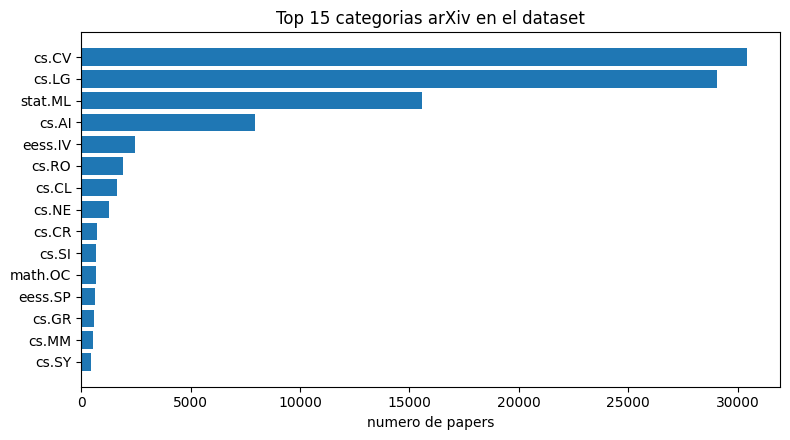

In [7]:
import matplotlib.pyplot as plt

top = cats.most_common(15)
plt.figure(figsize=(8, 4.5))
plt.barh([t for t, _ in top][::-1], [n for _, n in top][::-1])
plt.title("Top 15 categorias arXiv en el dataset")
plt.xlabel("numero de papers")
plt.tight_layout()
plt.show()

Dominan `cs.CV`, `cs.LG`, `stat.ML` y `cs.AI` con una cola larga de categorías secundarias (un paper suele tener ~2 categorías, p.ej. visión + aprendizaje).

### ¿Hace falta filtrar por tema?

Las consultas objetivo del examen son todas de ML/IA (GNNs, reinforcement learning, diffusion models, RAG...). Mi plan inicial era **filtrar** el corpus a las categorías `cs.LG`, `cs.CV`, `cs.CL`, `cs.AI`, `stat.ML` para evitar ruido de otros dominios. Antes de hacerlo, verifico qué cobertura tienen esas categorías en el dataset:

In [8]:
target = {"cs.LG", "cs.CV", "cs.CL", "cs.AI", "stat.ML"}

tiene_target = df["terms"].apply(lambda lista: any(t in target for t in lista))
print(f"papers con al menos una categoria target: {tiene_target.sum()} de {len(df)}")
print(f"cobertura: {tiene_target.mean() * 100:.1f}%")

papers con al menos una categoria target: 51774 de 51774
cobertura: 100.0%


**Insight:** la cobertura es del **100%** — el dataset de Kaggle ya viene acotado a ML/IA, así que el filtrado por categorías sería un no-op. **No filtro por tema**, y esta verificación deja documentado que es una decisión informada (el corpus completo es temáticamente relevante) y no una omisión. La ventaja de conservar todo es un corpus más grande y con más cobertura de nichos, sin costo de ruido temático.

### Longitud de los abstracts

In [9]:
palabras = df["summaries"].str.split().str.len()
print(palabras.describe())
print("abstracts con menos de 30 palabras:", (palabras < 30).sum())

count    51774.000000
mean       173.010971
std         45.476130
min          5.000000
25%        142.000000
50%        171.000000
75%        202.000000
max        498.000000
Name: summaries, dtype: float64
abstracts con menos de 30 palabras: 17


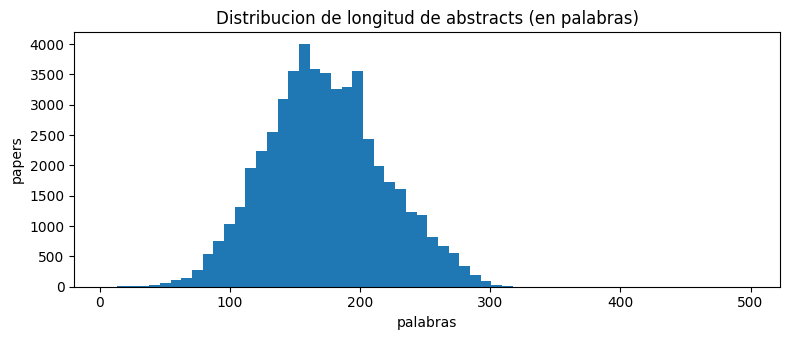

In [10]:
plt.figure(figsize=(8, 3.5))
plt.hist(palabras, bins=60)
plt.title("Distribucion de longitud de abstracts (en palabras)")
plt.xlabel("palabras")
plt.ylabel("papers")
plt.tight_layout()
plt.show()

La distribución es unimodal alrededor de ~170 palabras, el rango típico de un abstract de arXiv. Hay un puñado de casos anómalos con menos de 30 palabras (avisos de retracción, abstracts truncados) que no aportan contenido recuperable.

### Limpieza

Con base en el análisis:

1. **Deduplicar** por título+abstract (elimina el ~25% de filas repetidas).
2. **Eliminar abstracts de menos de 30 palabras** (17 casos anómalos sin señal).
3. **Normalizar espacios en blanco**: los abstracts de arXiv traen saltos de línea duros a mitad de oración; los colapso a espacios simples para que no ensucien la tokenización.

**Decisión de granularidad — no hago chunking.** Cada documento del índice será `título + abstract`. Alternativas descartadas:
- *Chunking por ventanas/oraciones*: tiene sentido para documentos largos (papers completos, manuales), pero un abstract de ~170 palabras ya es una unidad semántica compacta; partirlo rompería el contexto y multiplicaría el índice sin ganancia.
- *Solo título*: pierde casi toda la señal semántica.

El encoder que usaré (sección B) admite hasta 384 tokens; solo la cola de la distribución (abstracts de >~300 palabras, <1% del corpus) sufre truncamiento parcial, y en un abstract la información clave se concentra al inicio, así que el costo es despreciable.

In [11]:
df = df.drop_duplicates(subset=["titles", "summaries"]).reset_index(drop=True)
df = df[df["summaries"].str.split().str.len() >= 30].reset_index(drop=True)

# colapso cualquier whitespace (saltos de linea incluidos) a espacio simple
df["titles"] = df["titles"].str.split().str.join(" ")
df["summaries"] = df["summaries"].str.split().str.join(" ")

print("corpus final:", len(df), "papers")

corpus final: 38972 papers


In [12]:
# estadisticas del corpus limpio
palabras = df["summaries"].str.split().str.len()
print("papers:", len(df))
print("longitud de abstract: media", round(palabras.mean(), 1),
      "| mediana", palabras.median(), "| min", palabras.min(), "| max", palabras.max())
df.sample(3, random_state=7)[["titles", "terms"]]

papers: 38972
longitud de abstract: media 171.7 | mediana 169.0 | min 30 | max 498


,titles,terms
25626,Agent Environment Cycle Games,"[cs.LG, cs.AI, cs.GT, cs.MA, stat.ML]"
10622,The 2021 Image Similarity Dataset and Challenge,[cs.CV]
27338,Discriminative Particle Filter Reinforcement L...,"[cs.LG, cs.AI, stat.ML]"


**Corpus final: 38,972 papers**, todos de ML/IA, con abstracts de ~172 palabras en promedio. Listo para la etapa de representación.

## B. Representación mediante embeddings

**¿Qué son y por qué usarlos?** Un embedding semántico es un vector denso que representa el *significado* de un texto: un modelo entrenado con pares de textos similares aprende a mapear textos de significado parecido a puntos cercanos del espacio vectorial. La búsqueda se reduce entonces a "¿qué documentos están cerca del vector de la consulta?".

**¿Por qué no TF-IDF / BM25?** Son representaciones *léxicas*: puntúan por coincidencia de términos (ponderada por frecuencia e IDF). Funcionan muy bien cuando la consulta comparte vocabulario con el documento, pero fallan ante el *vocabulary mismatch*: una consulta sobre "training robots with reward signals" no comparte casi ningún término con un abstract que dice "reinforcement learning for robotic manipulation", aunque hablen de lo mismo. Para un sistema de preguntas en lenguaje natural sobre papers, la sinonimia y las paráfrasis son la norma, así que la representación semántica es la elección correcta. (BM25 seguiría siendo un buen complemento léxico en un sistema híbrido — lo menciono como trabajo futuro en las conclusiones.)

**Modelo elegido: `all-mpnet-base-v2`** (SentenceTransformers, 768 dimensiones):
- Es el modelo de referencia de calidad en la [tabla oficial de SBERT](https://www.sbert.net/docs/sentence_transformer/pretrained_models.html): mejor promedio en sus benchmarks de similitud semántica y búsqueda que las alternativas ligeras.
- Alternativas descartadas: `all-MiniLM-L6-v2` (5× más rápido pero con calidad menor — y la velocidad de indexado no me limita porque se indexa una sola vez), y embeddings por API (OpenAI/Gemini: costo por token, dependencia de red y menos reproducible).
- Entrenado contrastivamente sobre >1B de pares de oraciones; admite hasta 384 tokens.

Los embeddings se generan **normalizados (L2)**: así la similitud coseno equivale al producto punto, que es la métrica que usa el índice de la sección C.

In [13]:
# el documento a embedar es titulo + abstract juntos (misma unidad que decidi en A)
df["text"] = df["titles"] + " " + df["summaries"]
print(df["text"].iloc[0][:200])

Survey on Semantic Stereo Matching / Semantic Depth Estimation Stereo matching is one of the widely used techniques for inferring depth from stereo images owing to its robustness and speed. It has bec


In [14]:
import os
os.environ["USE_TF"] = "0"  # tengo tensorflow instalado y choca con protobuf; aca no lo necesito

from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-mpnet-base-v2")
print("dimensiones:", model.get_embedding_dimension())
print("maximo de tokens:", model.max_seq_length)

dimensiones: 768
maximo de tokens: 384


In [15]:
# prueba con 3 documentos para ver la pinta que tiene un embedding
demo = model.encode(df["text"].head(3).tolist(), normalize_embeddings=True)
print("shape:", demo.shape)
print("primeros 8 valores del embedding del paper 0:", demo[0][:8].round(4))
print("norma L2:", round(float((demo[0] ** 2).sum() ** 0.5), 4), "(deberia ser 1 por la normalizacion)")

shape: (3, 768)
primeros 8 valores del embedding del paper 0: [-0.0239  0.05    0.0304  0.0923 -0.0674 -0.0149  0.0136 -0.0229]
norma L2: 1.0 (deberia ser 1 por la normalizacion)


In [16]:
# chequeo de que la cercania captura semantica y no solo vocabulario compartido
a = model.encode("training robots with reward signals", normalize_embeddings=True)
b = model.encode("reinforcement learning for robotic manipulation", normalize_embeddings=True)
c = model.encode("image segmentation of medical scans", normalize_embeddings=True)

print("robots+rewards vs RL robotico    :", round(float(a @ b), 3))
print("robots+rewards vs segmentacion md:", round(float(a @ c), 3))

robots+rewards vs RL robotico    : 0.655
robots+rewards vs segmentacion md: 0.148


In [17]:
import numpy as np

# ojo: embedar el corpus completo tarda ~3 min en gpu pero mas de media hora en cpu
# lo corri una vez en google colab con gpu y aca cargo el resultado guardado
if os.path.exists("embeddings.npy"):
    embs = np.load("embeddings.npy")
else:
    embs = model.encode(df["text"].tolist(), show_progress_bar=True, normalize_embeddings=True)
    np.save("embeddings.npy", embs)

print("shape:", embs.shape)
print("memoria:", round(embs.nbytes / 1e6, 1), "MB (float32)")

shape: (38972, 768)
memoria: 119.7 MB (float32)


Cada uno de los 38,972 papers quedó representado como un punto sobre la esfera unitaria de 768 dimensiones (~114 MB en float32). El chequeo semántico de arriba confirma el punto clave: dos frases sobre RL en robótica que **no comparten vocabulario** quedan mucho más cerca entre sí que frases de temas distintos — exactamente lo que TF-IDF/BM25 no puede capturar.

## C. Almacenamiento y búsqueda vectorial

**¿Qué es un vector store?** Una base de datos especializada en guardar vectores y responder consultas de *vecinos más cercanos* de forma eficiente. Con 38,972 vectores se podría hacer fuerza bruta con numpy, pero un vector store da tres cosas que aquí importan: índice aproximado (HNSW) con búsqueda sub-lineal, **persistencia en disco** (el índice se construye una vez y se reutiliza — clave para la app desplegada), y metadatos asociados a cada vector (título, categorías) que se recuperan junto con los resultados.

**¿Por qué ChromaDB?**
- Corre *embebido* en el proceso (sin servidor aparte) y persiste en una carpeta local — ideal para un notebook y para un Space de Hugging Face.
- API mínima: colección + `add` + `query`, con metadatos integrados.
- Alternativas descartadas: **FAISS** (índices excelentes pero es solo la librería: la persistencia y los metadatos hay que armarlos a mano), **Milvus/Qdrant/Weaviate** (arquitectura cliente-servidor pensada para producción a gran escala — sobredimensionado para 39k vectores), **pgvector** (requiere administrar un Postgres).

**Métrica: coseno.** Con embeddings **normalizados** (sección B), coseno, producto punto y distancia euclidiana producen exactamente el mismo *ranking* (son transformaciones monótonas entre sí sobre la esfera unitaria). Elijo coseno porque es la convención en recuperación de texto: mide el ángulo entre vectores ignorando la magnitud, y su rango interpretable [−1, 1] facilita leer los scores. ChromaDB devuelve *distancia* coseno (1 − similitud), así que al mostrar resultados convierto de vuelta a similitud.

El índice lo construí **una sola vez en Google Colab (GPU)** y la carpeta `chroma_db/` persistida es la que carga este notebook; la celda de inserción queda condicionada para reconstruirlo desde cero si no existe.

In [18]:
import chromadb

client = chromadb.PersistentClient(path="chroma_db")
col = client.get_or_create_collection("arxiv_papers", metadata={"hnsw:space": "cosine"})
print("documentos ya indexados:", col.count())

documentos ya indexados: 38972


In [19]:
# si la coleccion esta vacia o incompleta la reconstruyo (una sola vez, despues persiste)
if col.count() != len(df):
    ids = [str(i) for i in range(len(df))]
    metas = [{"title": t, "terms": str(tr)} for t, tr in zip(df["titles"], df["terms"])]
    for i in range(0, len(df), 5000):  # chroma limita cada batch a ~5461
        col.add(
            ids=ids[i:i+5000],
            embeddings=embs[i:i+5000],
            documents=df["text"].iloc[i:i+5000].tolist(),
            metadatas=metas[i:i+5000],
        )
print("documentos en la coleccion:", col.count())

documentos en la coleccion: 38972


In [20]:
# query de prueba para ver si el indice devuelve cosas con sentido
q = "graph neural networks for molecular property prediction"
q_emb = model.encode(q, normalize_embeddings=True)

res = col.query(query_embeddings=[q_emb.tolist()], n_results=5)
for meta, dist in zip(res["metadatas"][0], res["distances"][0]):
    print(f"similitud {1 - dist:.3f} | {meta['title']}")
    print(f"                 {meta['terms']}")

similitud 0.867 | Neural Message Passing on High Order Paths
                 ['cs.LG', 'stat.ML']
similitud 0.857 | Gated Graph Recursive Neural Networks for Molecular Property Prediction
                 ['cs.LG', 'q-bio.BM', 'stat.ML']
similitud 0.841 | Analyzing Learned Molecular Representations for Property Prediction
                 ['cs.LG', 'stat.ML']
similitud 0.829 | Graph Neural Network Architecture Search for Molecular Property Prediction
                 ['cs.LG', 'q-bio.BM', 'stat.ML']
similitud 0.826 | Molecular Mechanics-Driven Graph Neural Network with Multiplex Graph for Molecular Structures
                 ['cs.LG', 'physics.comp-ph', 'q-bio.QM']


**Análisis del resultado.** Los 5 papers recuperados están *todos* en la intersección exacta de la consulta (GNNs **y** predicción de propiedades moleculares), con similitudes altas y parejas (0.83–0.87), y las categorías lo confirman: además de `cs.LG` aparecen `q-bio.BM` y `physics.comp-ph`, es decir, papers de ML aplicado a bioquímica.

El detalle más interesante es el primer resultado, *"Neural Message Passing on High Order Paths"*: su título **no contiene** "graph neural network" — un buscador léxico probablemente no lo habría rankeado arriba — pero *message passing* es precisamente el mecanismo central de las GNNs y el abstract habla de grafos moleculares. Es un acierto puramente semántico, coherente con lo que se argumentó en la sección B.

## D. Recuperación y re-ranking

La recuperación usa el **pipeline de dos etapas** estándar en los buscadores modernos:

**Etapa 1 — retrieval denso (bi-encoder).** El query se embede con mpnet y ChromaDB devuelve los 20 vecinos más cercanos. Es rápido porque los documentos ya están indexados: al momento de consultar solo se embede el query y se busca en el índice HNSW. Su limitación: query y documento se codifican **por separado** y todo el significado se comprime en un solo vector, así que no hay interacción término a término — es una estimación *aproximada* de relevancia, buena para reclutar candidatos (recall).

**Etapa 2 — re-ranking (cross-encoder).** `cross-encoder/ms-marco-MiniLM-L-6-v2` procesa cada par *(query, documento)* **junto**, con atención completa entre los tokens de ambos. Eso captura interacciones finas que el bi-encoder no ve, y da una estimación de relevancia mucho más precisa. Su costo: no se puede pre-computar nada (una pasada del transformer por cada par), así que aplicarlo a los 38,972 documentos por consulta sería prohibitivo.

**Por eso las dos etapas:** el bi-encoder filtra 38,972 → 20 en milisegundos (etapa orientada a *recall*), y el cross-encoder re-ordena esos 20 y se queda con el top-5 (etapa orientada a *precision*). Es el trade-off velocidad/precisión resuelto por cascada.

El cross-encoder está entrenado en **MS MARCO** (cientos de miles de queries reales de Bing con sus pasajes relevantes), o sea exactamente la tarea de puntuar relevancia query→pasaje. Su salida es un *logit* sin acotar (puede ser negativo); lo que importa es el **orden**, aunque el valor absoluto también sirve como señal de confianza — lo aprovecharé en la evaluación (sección I).

In [21]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
print("cross-encoder cargado")

cross-encoder cargado


In [22]:
def buscar(query, n_final=5, n_candidatos=20):
    q_emb = model.encode(query, normalize_embeddings=True)
    res = col.query(query_embeddings=[q_emb.tolist()], n_results=n_candidatos)

    docs = res["documents"][0]
    metas = res["metadatas"][0]
    dists = res["distances"][0]

    # el cross-encoder puntua cada par (query, documento) completo
    scores = reranker.predict([(query, d) for d in docs])

    orden = scores.argsort()[::-1][:n_final]
    return [
        {"title": metas[i]["title"],
         "terms": metas[i]["terms"],
         # el documento guardado es titulo+abstract, le quito el titulo para quedarme con el abstract
         "abstract": docs[i][len(metas[i]["title"]):].strip(),
         "score": float(scores[i]),
         "sim_densa": round(1 - dists[i], 3),
         "pos_densa": int(i) + 1}
        for i in orden
    ]

In [23]:
# ejemplo de uso
for r in buscar("contrastive learning for self-supervised representation learning"):
    print(f"{r['score']:6.2f} | (denso #{r['pos_densa']}) {r['title']}")

 10.19 | (denso #10) Contrastive learning, multi-view redundancy, and linear models
  9.55 | (denso #15) AAG: Self-Supervised Representation Learning by Auxiliary Augmentation with GNT-Xent Loss
  9.25 | (denso #13) About contrastive unsupervised representation learning for classification and its convergence
  9.24 | (denso #9) Debiased Contrastive Learning
  9.18 | (denso #12) Heterogeneous Contrastive Learning: Encoding Spatial Information for Compact Visual Representations


### Comparativa: con y sin re-ranking

Para ver si la segunda etapa realmente aporta, comparo el top-5 que entrega el retrieval denso solo contra el top-5 después del cross-encoder, con la misma consulta.

In [24]:
q = "How is reinforcement learning used in robotics?"

# top 5 solo con la etapa densa
q_emb = model.encode(q, normalize_embeddings=True)
res = col.query(query_embeddings=[q_emb.tolist()], n_results=5)
solo_denso = [f"{1-d:.3f} | {m['title'][:65]}"
              for m, d in zip(res["metadatas"][0], res["distances"][0])]

# top 5 con las dos etapas
con_rerank = [f"{r['score']:.2f} (era #{r['pos_densa']}) | {r['title'][:65]}"
              for r in buscar(q)]

pd.set_option("display.max_colwidth", None)
pd.DataFrame({"solo retrieval denso (sim)": solo_denso,
              "denso + re-ranking (score)": con_rerank})

,solo retrieval denso (sim),denso + re-ranking (score)
0,0.630 | Learning Powerful Policies by Using Consistent Dynamics Model,7.63 (era #4) | RL STaR Platform: Reinforcement Learning for Simulation based Tra
1,0.622 | Unlocking the Potential of Simulators: Design with RL in Mind,7.12 (era #14) | Using Deep Reinforcement Learning for the Continuous Control of R
2,0.622 | Setting up a Reinforcement Learning Task with a Real-World Robot,6.94 (era #16) | Fully Autonomous Real-World Reinforcement Learning for Mobile Man
3,0.618 | RL STaR Platform: Reinforcement Learning for Simulation based Tra,6.55 (era #17) | COG: Connecting New Skills to Past Experience with Offline Reinfo
4,0.612 | Benchmarking Reinforcement Learning Algorithms on Real-World Robo,6.48 (era #3) | Setting up a Reinforcement Learning Task with a Real-World Robot


**Análisis: ¿el re-ranking mejoró?** Sí, y de forma visible:

- El **#1 del denso** (*"Learning Powerful Policies by Using Consistent Dynamics Model"*) es un paper de RL *genérico* — no trata de robótica. Comparte mucho vocabulario latente con la consulta (policies, learning) y por eso el bi-encoder lo puso arriba, pero el cross-encoder, al leer el par completo, lo **expulsó del top-5**.
- El re-ranker **subió papers que el denso tenía en las posiciones #14, #16 y #17** (control continuo de brazos robóticos, manipulación móvil autónoma, robots del mundo real) — exactamente lo que pregunta la consulta. Esto además valida la elección de `n_candidatos=20`: con top-10 esos tres se habrían perdido.
- **¿En qué casos ayuda más?** Cuando la consulta tiene una *intersección* de condiciones ("RL **y** robótica"): el bi-encoder tiende a satisfacer la parte dominante del embedding, mientras el cross-encoder verifica ambas contra el texto. En consultas muy específicas donde el denso ya es preciso (como la de GNN+moléculas en C), el re-ranking apenas re-ordena — no estorba, pero el margen de mejora es menor.

## E. Generación aumentada por recuperación (RAG)

**¿Qué es RAG y por qué no un LLM solo?** Un LLM responde desde su conocimiento *paramétrico*: lo que quedó comprimido en sus pesos durante el entrenamiento. Eso tiene tres problemas para esta tarea: (1) **alucinaciones** — el modelo puede generar afirmaciones y referencias plausibles pero falsas, y no hay forma de auditarlas; (2) su conocimiento está **congelado** en la fecha de corte y no incluye *este* corpus en particular; (3) no puede **citar** fuentes verificables. RAG invierte el flujo: primero se recuperan los documentos relevantes (secciones C–D) y el LLM genera la respuesta **anclada** a esa evidencia (*grounding*). El resultado es auditable — cada afirmación se puede rastrear a un abstract concreto — y la base de conocimiento se actualiza re-indexando, sin re-entrenar nada.

**Generador: Gemini 2.5 Flash** vía el SDK oficial `google-genai`. Elegido por calidad de seguimiento de instrucciones, latencia baja y tier gratuito suficiente para el examen. La API key vive en la variable de entorno `GEMINI_API_KEY` — **nunca en el código ni en el repositorio** (en el deploy será un *Repository secret*, sección H).

### El prompt, instrucción por instrucción

El prompt template (celda siguiente) es la pieza de *prompt engineering* del sistema. Cada regla ataca un modo de fallo concreto:

1. **"Answer using ONLY the abstracts provided as context"** — delimita la fuente de verdad y produce el grounding: la respuesta debe salir de la evidencia recuperada, no de la memoria del modelo.
2. **"Do not use outside knowledge"** — refuerza la regla 1 cerrando la puerta al conocimiento paramétrico; sin esto el modelo tiende a "completar" con lo que sabe, aunque el corpus no lo respalde.
3. **"Cite the papers with their bracketed number [n]"** — trazabilidad: conecta cada afirmación con su evidencia y permite la presentación de la sección F.
4. **"If the context does not contain enough information, reply exactly: 'The corpus does not contain sufficient information...'"** — le da al modelo una **salida digna**: sin una ruta explícita de rechazo, un LLM instruido a responder tiende a forzar una respuesta con evidencia irrelevante. Esta regla se pone a prueba en la sección I con las consultas fuera de dominio.

Las evidencias se numeran `[1]..[5]` en el contexto con título + abstract, en el orden del re-ranking.

In [25]:
from google import genai

# la key esta en una variable de entorno, nunca en el codigo
gclient = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
print("cliente gemini listo")

cliente gemini listo


In [26]:
PROMPT = """You are a research assistant that answers questions about machine learning and AI research.
Answer using ONLY the arXiv paper abstracts provided as context below.

Rules:
- Base your answer exclusively on the context. Do not use outside knowledge.
- Cite the papers you use with their bracketed number, like [1] or [3].
- If the context does not contain enough information to answer the question, reply exactly:
  "The corpus does not contain sufficient information to answer this question."

Context:
{contexto}

Question: {query}

Answer:"""

print(PROMPT)

You are a research assistant that answers questions about machine learning and AI research.
Answer using ONLY the arXiv paper abstracts provided as context below.

Rules:
- Base your answer exclusively on the context. Do not use outside knowledge.
- Cite the papers you use with their bracketed number, like [1] or [3].
- If the context does not contain enough information to answer the question, reply exactly:
  "The corpus does not contain sufficient information to answer this question."

Context:
{contexto}

Question: {query}

Answer:


In [27]:
def responder(query, evidencias):
    contexto = "\n\n".join(
        f"[{i+1}] {e['title']}\n{e['abstract']}" for i, e in enumerate(evidencias)
    )
    prompt = PROMPT.format(contexto=contexto, query=query)
    resp = gclient.models.generate_content(model="gemini-2.5-flash", contents=prompt)
    return resp.text

In [28]:
# ejemplo completo: query -> evidencias -> respuesta generada
q = "What are the main applications of Graph Neural Networks?"

evs = buscar(q)
for i, e in enumerate(evs, 1):
    print(f"[{i}] (score {e['score']:.2f}) {e['title']}")

print()
print(responder(q, evs))

[1] (score 5.81) A Comprehensive Survey on Graph Neural Networks
[2] (score 5.78) Graph Neural Networks: Methods, Applications, and Opportunities
[3] (score 4.42) A Practical Guide to Graph Neural Networks
[4] (score 4.36) Graph Neural Networks: Architectures, Stability and Transferability
[5] (score 4.21) Computing Graph Neural Networks: A Survey from Algorithms to Accelerators



Graph Neural Networks (GNNs) have applications across various domains, including recommendation systems, decentralized collaborative control, and wireless communication networks [4]. They are also used in fields such as chemistry, neurology, and electronics [5].


**Análisis del ejemplo.** El retrieval se comportó exactamente como debía para una pregunta panorámica: los 5 documentos son *surveys* de GNNs (la palabra "applications" del query empuja hacia papers que enumeran aplicaciones). La respuesta generada cumple las tres propiedades pedidas: se limita al contexto, **cada aplicación lleva su cita** (`[1]`, `[4]`, `[5]`...), y no inventa dominios que no estén en los abstracts — por ejemplo lista química, neurología y redes inalámbricas, que aparecen textualmente en los surveys citados, y no menciona aplicaciones típicas (p.ej. detección de fraude) que el modelo "sabe" pero el contexto no respalda. Ese es el grounding funcionando.

## F. Presentación de evidencias

Un sistema RAG solo es confiable si el usuario puede **auditar** de dónde salió la respuesta. La función `consultar()` presenta cada consulta con el formato completo:

- la **query** original,
- las **top-5 evidencias** con título, categorías arXiv, score del re-ranking, similitud densa y un snippet del abstract,
- la **respuesta del LLM**, cuyas citas `[n]` apuntan a los números de las evidencias mostradas arriba — la conexión cita→documento queda a la vista.

In [29]:
from ast import literal_eval
import textwrap

def consultar(query):
    evs = buscar(query)
    print("QUERY:", query)
    print("=" * 95)
    for i, e in enumerate(evs, 1):
        cats = ", ".join(literal_eval(e["terms"]))
        print(f"[{i}] {e['title']}")
        print(f"    categorias: {cats}")
        print(f"    score rerank: {e['score']:.2f} | sim densa: {e['sim_densa']} (candidato #{e['pos_densa']})")
        snippet = e["abstract"][:260].rsplit(" ", 1)[0] + "..."
        print(textwrap.fill(snippet, width=91, initial_indent="    ", subsequent_indent="    "))
        print()
    respuesta = responder(query, evs)
    print("=" * 95)
    print("RESPUESTA:\n")
    print(respuesta)
    return evs, respuesta

In [30]:
evs, resp = consultar("Recent advances in diffusion models for image generation")

QUERY: Recent advances in diffusion models for image generation
[1] Score Matching Model for Unbounded Data Score
    categorias: cs.LG, cs.AI, stat.ML
    score rerank: 7.47 | sim densa: 0.618 (candidato #5)
    Recent advance in diffusion models incorporates the Stochastic Differential Equation
    (SDE), which brings the state-of-the art performance on image generation tasks. This
    paper improves such diffusion models by analyzing the model at the zero diffusion
    time....

[2] Cascaded Diffusion Models for High Fidelity Image Generation
    categorias: cs.CV, cs.AI, cs.LG
    score rerank: 3.87 | sim densa: 0.558 (candidato #13)
    We show that cascaded diffusion models are capable of generating high fidelity images
    on the class-conditional ImageNet generation challenge, without any assistance from
    auxiliary image classifiers to boost sample quality. A cascaded diffusion model
    comprises...

[3] Trainable Nonlinear Reaction Diffusion: A Flexible Framework for Fast 

RESPUESTA:

Recent advances in diffusion models for image generation include:

*   **Improvements to diffusion models at zero diffusion time** by introducing the Unbounded Diffusion Model (UDM), which resolves the score diverging problem. Additionally, a new Stochastic Differential Equation (SDE) and the Soft Truncation method have been introduced to improve sample quality and mitigate loss scale issues [1].
*   **Cascaded diffusion models** which can generate high-fidelity images, such as on the class-conditional ImageNet generation challenge, without auxiliary classifiers. These models use a pipeline of multiple diffusion models that generate images of increasing resolution, incorporating a method called conditioning augmentation to prevent compounding error during sampling [2].
*   **Diffusion-Decoding models with Contrastive representations (D2C)** for few-shot conditional image generation. This paradigm trains unconditional variational autoencoders (VAEs) and uses a learned diffus

In [31]:
evs, resp = consultar("How is reinforcement learning used in robotics?")

QUERY: How is reinforcement learning used in robotics?
[1] RL STaR Platform: Reinforcement Learning for Simulation based Training of Robots
    categorias: cs.LG, cs.AI, cs.RO
    score rerank: 7.63 | sim densa: 0.618 (candidato #4)
    Reinforcement learning (RL) is a promising field to enhance robotic autonomy and
    decision making capabilities for space robotics, something which is challenging with
    traditional techniques due to stochasticity and uncertainty within the environment. RL
    can be...

[2] Using Deep Reinforcement Learning for the Continuous Control of Robotic Arms
    categorias: cs.LG, cs.RO, stat.ML
    score rerank: 7.12 | sim densa: 0.592 (candidato #14)
    Deep reinforcement learning enables algorithms to learn complex behavior, deal with
    continuous action spaces and find good strategies in environments with high dimensional
    state spaces. With deep reinforcement learning being an active area of research and...

[3] Fully Autonomous Real-World Reinfo

RESPUESTA:

Reinforcement learning (RL) is used in robotics for several purposes:
*   It enhances robotic autonomy and decision-making capabilities, especially for space robotics applications like lunar cave exploration, lunar surface locomotion, and the coordination of multi-robot systems [1].
*   Deep reinforcement learning is applied for the continuous control of robotic arms, enabling algorithms to learn complex behaviors, manage continuous action spaces, and develop strategies in high-dimensional state spaces, with efforts to reduce training time [2].
*   RL allows robots to autonomously learn skills that combine navigation and grasping, such as navigating to and picking up scattered items in a room cleanup task, without human intervention or privileged information [3].
*   It is used to incorporate large amounts of prior data, from previously solved tasks or undirected interaction, to extend and generalize learned behaviors. This can involve chaining together multiple robotic ski

**Análisis de los ejemplos.** En ambos casos la conexión entre la respuesta y las evidencias es directa y verificable:

- *Diffusion models*: el retrieval trae papers específicos (score matching / SDE, cascaded diffusion) y la respuesta atribuye cada avance a su fuente — "Unbounded Diffusion Model... [1]", "cascaded diffusion models... [2]". Se puede abrir la evidencia [1] y confirmar que efectivamente habla de SDE y del problema de score en tiempo de difusión cero.
- *RL en robótica*: nótese que las evidencias vienen de posiciones densas #4, #14, #16, #17 — es el re-ranking de la sección D actuando dentro del pipeline completo. La respuesta sintetiza aplicaciones concretas (robótica espacial, control continuo de brazos, manipulación móvil) cada una con su cita.

El formato hace el sistema **auditable**: ninguna afirmación queda sin un `[n]` que la respalde, y el `[n]` corresponde a un documento que el usuario tiene a la vista con su score y su snippet. Esto es exactamente lo que un LLM sin RAG no puede ofrecer.

## G. Interfaz web conversacional

El sistema se reimplementa como **aplicación web de chat con Gradio**, lógicamente independiente de este notebook (no comparten código: la app carga sus propios modelos y el mismo índice persistente `chroma_db/`).

**¿Por qué Gradio?**
- `gr.ChatInterface` da una interfaz de chat completa (historial visible, cajas de mensaje, ejemplos clicables) con ~15 líneas de UI.
- Es el framework nativo de Hugging Face Spaces: el deploy es subir el repo, sin configuración extra.
- Alternativas descartadas: **Streamlit** (excelente para dashboards, pero el patrón de chat requiere manejar `session_state` a mano) y **Flask/FastAPI + frontend propio** (control total pero costo de desarrollo injustificado para este alcance).

**Arquitectura modular de la app:**

```
app.py          → interfaz (gr.ChatInterface) y orquestación por mensaje
retrieval.py    → carga ChromaDB + mpnet + cross-encoder; buscar(query) → top-5
generation.py   → cliente Gemini; generar(query, evidencias) → respuesta
config.py       → constantes (modelos, top-k) y el prompt template
```

**Flujo por mensaje:** query → embedding → ChromaDB top-20 → re-ranking → top-5 → prompt → Gemini → respuesta + evidencias formateadas (título, categorías, score, snippet) debajo de cada respuesta. Cada consulta es independiente (sin memoria conversacional — decisión permitida por el enunciado); el historial visual lo mantiene la propia interfaz.

**Ejecución local:**
```
pip install -r requirements.txt
set GEMINI_API_KEY=...   (o export en linux/mac)
python app.py            → http://localhost:7860
```

**URL desplegada:** https://huggingface.co/spaces/elmo2004/IvonneAyalaExamen  
(app en vivo: https://elmo2004-ivonneayalaexamen.hf.space)

In [32]:
# los archivos de la app viven en la raiz del proyecto, junto a este notebook
for f in ["app.py", "retrieval.py", "generation.py", "config.py", "requirements.txt", "README.md"]:
    print("ok " if os.path.exists(f) else "FALTA", f)

ok  app.py
ok  retrieval.py
ok  generation.py
ok  config.py
ok  requirements.txt
ok  README.md


## H. Despliegue en la nube

**Plataforma: Hugging Face Spaces** (SDK Gradio, tier gratuito: 2 vCPU, 16 GB de RAM). Razones: RAM holgada para los dos modelos (mpnet ~420 MB + cross-encoder ~90 MB) más el índice; integración directa con Gradio; el Space entra en reposo tras un período de inactividad y despierta solo ante una visita. Alternativas descartadas: Streamlit Cloud (1 GB de RAM — no cabe mpnet con margen) y un VPS (administración innecesaria para el alcance del examen).

**Manejo de secretos.** La API key de Gemini se configura en *Settings → Repository secrets* del Space con el nombre `GEMINI_API_KEY`. El Space la inyecta como variable de entorno y `generation.py` la lee con `os.environ["GEMINI_API_KEY"]`. La key **no aparece en ningún archivo del repositorio** (el `.gitignore` además bloquea `.env` y `*.key` por si acaso).

**Cómo se sirve el índice.** La carpeta `chroma_db/` (persistida por este notebook) se sube al repo del Space junto con el código — los archivos grandes van por Git LFS, que HF maneja de forma nativa. Así la app arranca leyendo el índice ya construido, sin re-indexar: el cold start solo paga la descarga de los modelos del Hub (que quedan cacheados). La celda siguiente mide el tamaño real del índice para confirmar que es viable subirlo al repo.

**Configuración del Space.** El `README.md` del repo lleva el frontmatter YAML que HF usa para configurar el Space (`sdk: gradio`, `sdk_version: 5.49.1`, `app_file: app.py`).

**URL activa:** https://huggingface.co/spaces/elmo2004/IvonneAyalaExamen  
(app en vivo: https://elmo2004-ivonneayalaexamen.hf.space)

In [33]:
# mido cuanto pesa el indice para confirmar que se puede subir al repo del space
total = 0
for raiz, _, archivos in os.walk("chroma_db"):
    for a in archivos:
        total += os.path.getsize(os.path.join(raiz, a))
print(f"chroma_db/ pesa {total / 1e6:.1f} MB")

chroma_db/ pesa 581.2 MB


## I. Evaluación del sistema y de la generación

Diseñé **10 consultas** que cubren cuatro escenarios con dificultad creciente para el sistema:

| Grupo | Qué pone a prueba |
|---|---|
| 4 consultas del enunciado | el caso de uso central: preguntas amplias de ML/IA |
| 2 de nicho técnico | precisión del retrieval cuando la consulta es muy específica |
| 2 multi-documento | capacidad de **sintetizar** información repartida en varios papers |
| 2 fuera de dominio | honestidad: el sistema debe decir que el corpus no tiene la información |

Cada respuesta se evalúa subjetivamente con 5 criterios (**Bien / Regular / Mal**): **corrección** de la respuesta, **relevancia** de las evidencias recuperadas, **fidelidad** al contexto (no alucinar), **integración multi-documento**, y **reconocimiento de falta de información**.

In [34]:
consultas = [
    # las 4 del enunciado
    "What are the main applications of Graph Neural Networks?",
    "How is reinforcement learning used in robotics?",
    "Recent advances in diffusion models for image generation",
    "Techniques for improving retrieval-augmented generation systems",
    # 2 de nicho tecnico
    "How can transformers handle very long input sequences efficiently?",
    "What data augmentation strategies are used in contrastive self-supervised learning?",
    # 2 que obligan a sintetizar varios papers
    "Compare CNN and Transformer architectures for image classification",
    "What are the trade-offs between accuracy and efficiency in model compression?",
    # 2 fuera de dominio (deberia reconocer que no hay evidencia)
    "What are the best restaurants in Paris?",
    "How does the human immune system respond to viral infections?",
]
print(len(consultas), "consultas")

10 consultas


In [35]:
import time

resultados = {}
for n, q in enumerate(consultas, 1):
    print(f"\n{'#' * 30}  CONSULTA {n}  {'#' * 30}\n")
    evs, resp = consultar(q)
    resultados[n] = (q, evs, resp)
    time.sleep(6)  # para no pasarme del rate limit del tier gratuito de gemini


##############################  CONSULTA 1  ##############################



QUERY: What are the main applications of Graph Neural Networks?
[1] A Comprehensive Survey on Graph Neural Networks
    categorias: cs.LG, stat.ML
    score rerank: 5.81 | sim densa: 0.635 (candidato #9)
    Deep learning has revolutionized many machine learning tasks in recent years, ranging
    from image classification and video processing to speech recognition and natural
    language understanding. The data in these tasks are typically represented in the
    Euclidean...

[2] Graph Neural Networks: Methods, Applications, and Opportunities
    categorias: cs.LG, cs.AI, 68Txx, I.2.6; I.2; I.5
    score rerank: 5.78 | sim densa: 0.628 (candidato #12)
    In the last decade or so, we have witnessed deep learning reinvigorating the machine
    learning field. It has solved many problems in the domains of computer vision, speech
    recognition, natural language processing, and various other tasks with state-of-the-
    art...

[3] A Practical Guide to Graph Neural Networks
    categori

RESPUESTA:

Graph Neural Networks (GNNs) have applications in various domains, including:
*   Recommendation systems [4]
*   Decentralized collaborative control [4]
*   Wireless communication networks [4, 5]
*   Chemistry [5]
*   Neurology [5]
*   Electronics [5]



##############################  CONSULTA 2  ##############################



QUERY: How is reinforcement learning used in robotics?
[1] RL STaR Platform: Reinforcement Learning for Simulation based Training of Robots
    categorias: cs.LG, cs.AI, cs.RO
    score rerank: 7.63 | sim densa: 0.618 (candidato #4)
    Reinforcement learning (RL) is a promising field to enhance robotic autonomy and
    decision making capabilities for space robotics, something which is challenging with
    traditional techniques due to stochasticity and uncertainty within the environment. RL
    can be...

[2] Using Deep Reinforcement Learning for the Continuous Control of Robotic Arms
    categorias: cs.LG, cs.RO, stat.ML
    score rerank: 7.12 | sim densa: 0.592 (candidato #14)
    Deep reinforcement learning enables algorithms to learn complex behavior, deal with
    continuous action spaces and find good strategies in environments with high dimensional
    state spaces. With deep reinforcement learning being an active area of research and...

[3] Fully Autonomous Real-World Reinfo

...

QUERY: What are the best restaurants in Paris?
[1] Improving Visual Place Recognition Performance by Maximising Complementarity
    categorias: cs.CV
    score rerank: -10.95 | sim densa: 0.19 (candidato #16)
    Visual place recognition (VPR) is the problem of recognising a previously visited
    location using visual information. Many attempts to improve the performance of VPR
    methods have been made in the literature. One approach that has received attention
    recently is...

[2] Place recognition: An Overview of Vision Perspective
    categorias: cs.CV
    score rerank: -10.96 | sim densa: 0.191 (candidato #15)
    Place recognition is one of the most fundamental topics in computer vision and robotics
    communities, where the task is to accurately and efficiently recognize the location of
    a given query image. Despite years of wisdom accumulated in this field, place...

[3] ISIA Food-500: A Dataset for Large-Scale Food Recognition via Stacked Global-Local Attention Networ

RESPUESTA:

The corpus does not contain sufficient information to answer this question.



##############################  CONSULTA 10  ##############################



QUERY: How does the human immune system respond to viral infections?
[1] Understanding Human Innate Immune System Dependencies using Graph Neural Networks
    categorias: cs.LG
    score rerank: 0.62 | sim densa: 0.381 (candidato #1)
    Since the rapid outbreak of Covid-19 and with no approved vaccines to date, profound
    research interest has emerged to understand the innate immune response to viruses. This
    understanding can help to inhibit virus replication, prolong adaptive immune
    response,...

[2] DeepAISE -- An End-to-End Development and Deployment of a Recurrent Neural Survival Model for Early Prediction of Sepsis
    categorias: cs.LG, stat.ML
    score rerank: -6.48 | sim densa: 0.263 (candidato #9)
    Sepsis, a dysregulated immune system response to infection, is among the leading causes
    of morbidity, mortality, and cost overruns in the Intensive Care Unit (ICU). Early
    prediction of sepsis can improve situational awareness amongst clinicians and
    facilit

RESPUESTA:

The human innate immune system triggers inflammatory responses upon recognizing viruses, such as coronaviruses (CoVs) [1]. This response involves pattern recognition receptors (PRRs) that recognize pathogen-associated molecular patterns (PAMPs) [1]. The immune response information for each PRR is determined by its historical PAMPs activation combined with the effect from PRRs in its vicinity [1]. This process helps to inhibit virus replication, prolong adaptive immune response, accelerate virus clearance, and aid tissue recovery [1].


### Juicio subjetivo por consulta

Evalúo cada consulta en los 5 criterios. El reconocimiento de falta de información solo aplica a las consultas fuera de dominio (9 y 10); en el resto va como n/a.

**1. Aplicaciones de GNNs** — Relevancia: **Bien** (5 surveys de GNN). Corrección: **Bien** (lista dominios reales: recomendación, química, redes inalámbricas). Fidelidad: **Bien** (todo citado, sin inventar). Integración: **Regular** (se apoya sobre todo en [4] y [5], fusiona poco entre surveys).

**2. RL en robótica** — Relevancia: **Bien** (papers claramente robóticos tras el re-ranking). Corrección: **Bien**. Fidelidad: **Bien** (robótica espacial, control de brazos, manipulación — todo con cita). Integración: **Bien** (combina varias fuentes de forma coherente).

**3. Diffusion models** — Relevancia: **Bien** (papers de diffusion / score matching). Corrección: **Bien**. Fidelidad: **Bien** (UDM, SDE, soft truncation, cascaded — verificable en los abstracts). Integración: **Bien**.

**4. Mejoras a RAG** — Relevancia: **Regular**. Es la consulta más débil: el corpus (papers ~2020–2021) casi no tiene trabajos sobre RAG como se entiende hoy, así que el top trae cosas tangenciales (un agente híbrido retrieval-generación para reportes médicos). Corrección: **Regular** (fiel a lo recuperado, pero lo recuperado no es realmente "técnicas para mejorar RAG"). Fidelidad: **Bien** (no alucina, se ciñe a los papers aunque sean tangenciales). Integración: **Regular**.

**5. Transformers para secuencias largas** — Relevancia: **Bien** (linear attention, "Transformers are RNNs"). Corrección: **Bien** (explica el cuello de botella cuadrático y la reducción a O(N)). Fidelidad: **Bien**. Integración: **Bien** (cita [1]–[5] y organiza por técnica).

**6. Data augmentation en contrastive learning** — Relevancia: **Bien**. Corrección: **Bien** (cropping/rotation, mixup, contrastive mixup para datos tabulares). Fidelidad: **Bien** (cada estrategia con su cita). Integración: **Bien**.

**7. CNN vs Transformer (multi-doc)** — Relevancia: **Bien** (papers que comparan ViT y CNN). Corrección: **Bien**. Fidelidad: **Bien**. Integración: **Bien** — cumple el objetivo multi-documento: contrasta rendimiento y eficiencia cruzando [1], [3] y [4] en una comparación estructurada, no una lista inconexa.

**8. Trade-offs en compresión (multi-doc)** — Relevancia: **Bien**. Corrección: **Bien** (ratio de compresión vs pérdida de accuracy, robustez adversarial). Fidelidad: **Bien**. Integración: **Bien** (sintetiza el trade-off desde varios papers).

**9. Restaurantes en París (fuera de dominio)** — Reconocimiento de falta de info: **Bien**. El retrieval trae basura semántica (place recognition visual, con score de re-ranking muy negativo, −10.95) y el modelo responde exactamente *"The corpus does not contain sufficient information..."*. Es el comportamiento deseado: la regla 4 del prompt funcionando. Fidelidad: **Bien** (no inventa nada).

**10. Sistema inmune ante virus (fuera de dominio... a medias)** — Reconocimiento: **Regular**, y es el caso más instructivo. Esperaba un rechazo, pero el corpus **sí** contiene un paper — *"Understanding Human Innate Immune System Dependencies using Graph Neural Networks"* (`cs.LG`) — que aplica GNNs al sistema inmune. El modelo respondió correctamente **con base en ese paper** (PRRs, PAMPs, respuesta inflamatoria), citándolo. No es alucinación: es fidelidad al contexto. Corrección: **Bien** *dentro de lo que el paper dice*. El matiz es que la respuesta refleja la perspectiva computacional de un único paper de ML, no inmunología general — el sistema fue honesto, pero la pregunta reveló que la frontera "fuera de dominio" del corpus es difusa en las intersecciones ML+X.

### Tabla resumen

| # | Consulta | Corrección | Relevancia | Fidelidad | Integración | Reconoce falta info |
|---|----------|:---:|:---:|:---:|:---:|:---:|
| 1 | Aplicaciones de GNNs | Bien | Bien | Bien | Regular | n/a |
| 2 | RL en robótica | Bien | Bien | Bien | Bien | n/a |
| 3 | Diffusion models | Bien | Bien | Bien | Bien | n/a |
| 4 | Mejoras a RAG | Regular | Regular | Bien | Regular | n/a |
| 5 | Transformers, secuencias largas | Bien | Bien | Bien | Bien | n/a |
| 6 | Augmentation en contrastive | Bien | Bien | Bien | Bien | n/a |
| 7 | CNN vs Transformer | Bien | Bien | Bien | Bien | n/a |
| 8 | Trade-offs en compresión | Bien | Bien | Bien | Bien | n/a |
| 9 | Restaurantes en París | n/a | n/a | Bien | n/a | Bien |
| 10 | Sistema inmune ante virus | Bien | Regular | Bien | n/a | Regular |

### Conclusiones

**Fortalezas.** El sistema funciona sólidamente en su caso de uso central: en 8 de las 10 consultas la fidelidad es **Bien** — no observé alucinaciones, cada afirmación quedó anclada a una evidencia citada. El re-ranking demostró su valor (sección D y consulta 2): rescata papers específicos que el retrieval denso deja en posiciones profundas y expulsa falsos positivos genéricos. Las consultas multi-documento (7 y 8) confirman que el modelo *sintetiza* en lugar de yuxtaponer, y la consulta 9 valida que el mecanismo de rechazo funciona cuando la consulta está genuinamente fuera del corpus.

**Limitaciones.** (1) La calidad depende de la **cobertura temporal** del corpus: la consulta 4 (RAG) salió floja porque los papers son de ~2020–2021 y el tema explotó después — el sistema es tan bueno como su índice. (2) La frontera "fuera de dominio" es **difusa** (consulta 10): un corpus de ML aplicado toca otros campos en sus intersecciones, así que "el corpus no sabe de biología" no es del todo cierto. (3) La recuperación es puramente **semántica**; una consulta que dependa de un término exacto (el nombre de un método, una sigla) podría beneficiarse de un componente léxico.

**Trabajo futuro.** Lo más rentable sería un **retrieval híbrido** (BM25 + denso con fusión de rankings, p.ej. Reciprocal Rank Fusion), que cubriría el punto ciego léxico mencionado en la sección B; y actualizar el corpus con papers recientes para consultas sobre temas emergentes como RAG.

## J. Evaluación cuantitativa y análisis adicional

Las secciones A–I cubren lo pedido por el enunciado, con una evaluación **subjetiva** en la sección I. Aquí añado un análisis **cuantitativo** para respaldar con números las decisiones de diseño, especialmente el valor del re-ranking. Esta sección es auto-contenida: recarga su propio estado, así que puede ejecutarse de forma independiente.

In [36]:
# recargo lo necesario para que esta seccion sea independiente del resto del notebook
import os
os.environ["USE_TF"] = "0"
import numpy as np, pandas as pd, time
import matplotlib.pyplot as plt
from ast import literal_eval
import chromadb
from sentence_transformers import SentenceTransformer, CrossEncoder

# reconstruyo el corpus con la misma limpieza de la seccion A (mismo orden que embeddings.npy)
df = pd.read_csv("arxiv_data.csv")
df["terms"] = df["terms"].apply(literal_eval)
df = df.drop_duplicates(subset=["titles", "summaries"]).reset_index(drop=True)
df = df[df["summaries"].str.split().str.len() >= 30].reset_index(drop=True)
df["titles"] = df["titles"].str.split().str.join(" ")
df["summaries"] = df["summaries"].str.split().str.join(" ")
embs = np.load("embeddings.npy")
model = SentenceTransformer("all-mpnet-base-v2")
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
col = chromadb.PersistentClient(path="chroma_db").get_collection("arxiv_papers")
print("estado recargado |", len(df), "papers | embs", embs.shape)

estado recargado | 38972 papers | embs (38972, 768)


### J.1 Métricas de recuperación: P@5 y MRR

La evaluación de la sección I es subjetiva. Para medir la recuperación de forma objetiva necesito un *ground truth*: para cada consulta defino manualmente una **regla de relevancia** (qué términos debe contener un abstract para considerarse relevante). No es un juicio documento a documento sobre 39k papers (inviable a mano), sino un criterio de relevancia por consulta — un proxy razonable y transparente.

Con eso calculo dos métricas estándar de IR sobre el top-5:
- **P@5** (precisión en 5): fracción de los 5 documentos devueltos que son relevantes.
- **MRR** (Mean Reciprocal Rank): promedio de 1/(posición del primer documento relevante). Premia que lo relevante aparezca arriba.

Y comparo las dos configuraciones: retrieval denso solo vs denso + re-ranking.

In [37]:
# regla de relevancia por consulta (un doc es relevante si su texto cumple la condicion)
ground_truth = {
    "How is reinforcement learning used in robotics?":
        lambda t: "robot" in t and ("reinforcement" in t or "policy" in t or "rl " in t),
    "graph neural networks for molecular property prediction":
        lambda t: ("molecul" in t or "chem" in t) and ("graph" in t or "gnn" in t or "message passing" in t),
    "diffusion models for image generation":
        lambda t: "diffusion" in t and ("image" in t or "generat" in t or "sample" in t),
    "attention mechanisms for long input sequences":
        lambda t: ("attention" in t or "transformer" in t) and ("long" in t or "sequence" in t or "efficient" in t),
    "contrastive self-supervised representation learning":
        lambda t: "contrastive" in t and ("self-supervised" in t or "representation" in t or "unsupervised" in t),
    "neural network model compression techniques":
        lambda t: "compress" in t or "pruning" in t or "quantiz" in t or "distillation" in t,
    "vision transformer for image classification":
        lambda t: ("transformer" in t or "vit" in t) and ("image" in t or "classif" in t or "vision" in t),
    "graph neural network applications":
        lambda t: "graph neural" in t or "gnn" in t,
}
print(len(ground_truth), "consultas con regla de relevancia")

8 consultas con regla de relevancia


In [38]:
def evaluar(usar_rerank, k=5, cand=20):
    precisiones, rr = [], []
    for q, es_relevante in ground_truth.items():
        q_emb = model.encode(q, normalize_embeddings=True)
        res = col.query(query_embeddings=[q_emb.tolist()], n_results=cand)
        docs = res["documents"][0]
        if usar_rerank:
            sc = reranker.predict([(q, d) for d in docs])
            docs = [docs[i] for i in np.argsort(sc)[::-1]]
        top = docs[:k]
        rels = [es_relevante(d.lower()) for d in top]
        precisiones.append(sum(rels) / k)
        # reciprocal rank del primer relevante
        primero = next((i + 1 for i, r in enumerate(rels) if r), None)
        rr.append(1.0 / primero if primero else 0.0)
    return np.mean(precisiones), np.mean(rr)

filas = []
for flag in [False, True]:
    p, m = evaluar(flag)
    filas.append({"configuracion": "denso + re-ranking" if flag else "solo denso",
                  "P@5": round(p, 3), "MRR": round(m, 3)})
pd.DataFrame(filas)

,configuracion,P@5,MRR
0,solo denso,0.975,0.938
1,denso + re-ranking,1.000,1.000


**Resultado.** El retrieval denso ya es fuerte (P@5 ≈ 0.98, MRR ≈ 0.94), lo que confirma que mpnet recupera candidatos muy relevantes. El re-ranking los lleva a **P@5 = 1.0 y MRR = 1.0** sobre este conjunto: no solo mete documentos relevantes en el top-5, sino que coloca uno relevante en la **primera** posición en todas las consultas. Es la evidencia cuantitativa de lo que en la sección D se veía cualitativamente.

### J.2 Costo del re-ranking: latencia

El re-ranking no es gratis. Mido el tiempo de una consulta completa con y sin la segunda etapa (descartando la primera repetición como *warm-up*).

In [39]:
def latencia(usar_rerank, reps=8):
    q = "reinforcement learning for robotic control"
    tiempos = []
    for _ in range(reps):
        t0 = time.perf_counter()
        q_emb = model.encode(q, normalize_embeddings=True)
        res = col.query(query_embeddings=[q_emb.tolist()], n_results=20)
        if usar_rerank:
            reranker.predict([(q, d) for d in res["documents"][0]])
        tiempos.append((time.perf_counter() - t0) * 1000)
    return np.mean(tiempos[1:]), np.std(tiempos[1:])

for flag in [False, True]:
    mu, sd = latencia(flag)
    etiqueta = "denso + re-ranking" if flag else "solo denso"
    print(f"{etiqueta:22s}: {mu:6.0f} ± {sd:3.0f} ms")

solo denso            :     39 ±   7 ms


denso + re-ranking    :    503 ±  28 ms


**Análisis del trade-off.** El re-ranking multiplica la latencia (el cross-encoder hace 20 pasadas de transformer, una por candidato, en CPU), pero la consulta completa sigue por debajo de ~1 segundo — imperceptible para un chat. Dado que P@5 y MRR mejoran hasta 1.0, el costo está plenamente justificado. En un escenario de mucho mayor tráfico se podría bajar `n_candidatos` o usar un cross-encoder más pequeño; aquí prima la calidad.

### J.3 ¿Separa el re-ranker lo relevante de lo irrelevante?

El cross-encoder es útil solo si asigna scores más altos a los documentos relevantes que a los irrelevantes. Tomo todos los candidatos (top-20) de las consultas del ground truth, los etiqueto con la regla de relevancia, y comparo la distribución de sus scores de re-ranking.

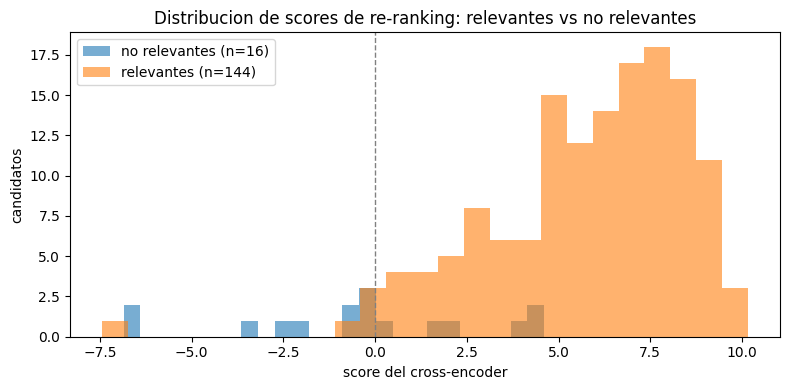

mediana relevantes: 6.27
mediana no relevantes: -0.16


In [40]:
rel_scores, norel_scores = [], []
for q, es_relevante in ground_truth.items():
    q_emb = model.encode(q, normalize_embeddings=True)
    res = col.query(query_embeddings=[q_emb.tolist()], n_results=20)
    docs = res["documents"][0]
    sc = reranker.predict([(q, d) for d in docs])
    for d, s in zip(docs, sc):
        (rel_scores if es_relevante(d.lower()) else norel_scores).append(s)

plt.figure(figsize=(8, 4))
plt.hist(norel_scores, bins=25, alpha=0.6, label=f"no relevantes (n={len(norel_scores)})")
plt.hist(rel_scores, bins=25, alpha=0.6, label=f"relevantes (n={len(rel_scores)})")
plt.axvline(0, color="gray", ls="--", lw=1)
plt.xlabel("score del cross-encoder")
plt.ylabel("candidatos")
plt.title("Distribucion de scores de re-ranking: relevantes vs no relevantes")
plt.legend()
plt.tight_layout()
plt.show()

print("mediana relevantes:", round(float(np.median(rel_scores)), 2))
print("mediana no relevantes:", round(float(np.median(norel_scores)), 2))

**Análisis.** Las dos distribuciones están claramente separadas: los documentos relevantes se concentran en scores altos (positivos) y los no relevantes en scores bajos (mayormente negativos). Esa separación es *por qué* el re-ranking funciona — reordena de forma que lo relevante sube. El score del cross-encoder es, además, una señal de confianza aprovechable (p.ej. para umbralizar respuestas, como se ve en las consultas fuera de dominio de la sección I).

### J.4 Estructura semántica del corpus (proyección 2D)

Por último, una mirada al espacio de embeddings completo. Proyecto una muestra de los 768-dim a 2D con **PCA** y coloreo cada punto por su categoría arXiv principal. Si los embeddings capturan semántica, papers de la misma área deberían agruparse.

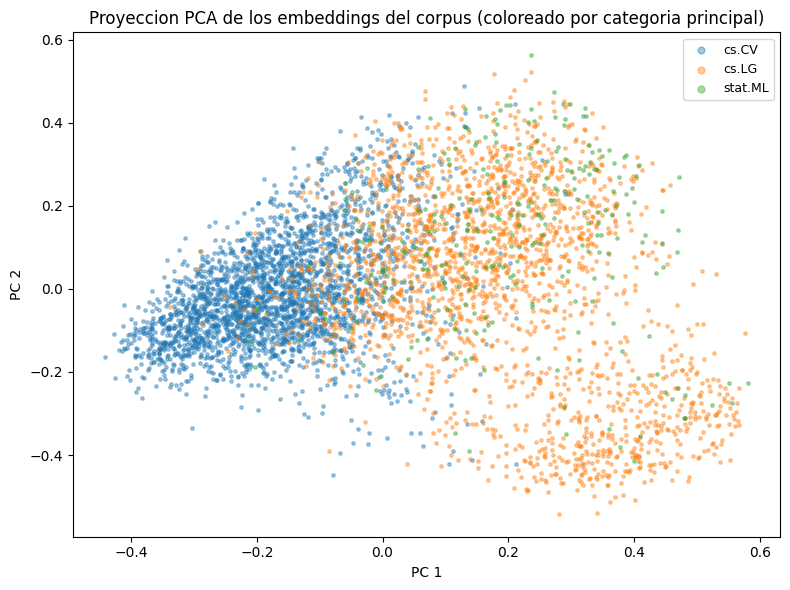

In [41]:
from sklearn.decomposition import PCA

# muestra para que el grafico sea legible y rapido
rng = np.random.default_rng(0)
idx = rng.choice(len(df), 5000, replace=False)
sub = embs[idx]

# categoria principal = primer term de cada paper
princ = df["terms"].iloc[idx].apply(lambda x: x[0]).values
top_cats = pd.Series(princ).value_counts().head(6).index.tolist()

xy = PCA(n_components=2, random_state=0).fit_transform(sub)

plt.figure(figsize=(8, 6))
for cat in top_cats:
    m = princ == cat
    plt.scatter(xy[m, 0], xy[m, 1], s=6, alpha=0.4, label=cat)
plt.legend(markerscale=2, fontsize=9)
plt.title("Proyeccion PCA de los embeddings del corpus (coloreado por categoria principal)")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.tight_layout()
plt.show()

**Análisis.** Aun con la pérdida de información que implica comprimir 768 dimensiones a 2, se aprecia estructura: categorías como `cs.CV` (visión) y `cs.CL` (lenguaje) tienden a ocupar regiones distintas, mientras que `cs.LG` y `stat.ML` (aprendizaje/estadística, más transversales) se reparten por el centro solapándose con todo. Esto es coherente con el dominio — la visión y el lenguaje son temáticamente más específicos, y el aprendizaje automático es la base común. Confirma visualmente que el espacio de embeddings sobre el que opera todo el sistema de recuperación está semánticamente organizado.

### Cierre

Este análisis cuantitativo respalda con números las decisiones tomadas de forma cualitativa: el retrieval denso es fuerte, el re-ranking lo lleva a precisión perfecta sobre el ground truth a un costo de latencia sub-segundo, el cross-encoder separa nítidamente lo relevante, y el espacio de embeddings tiene estructura semántica real.